In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("../data/raw/e-shop_clothing_2008.csv", sep=";")
df

,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page
0,2008,4,1,1,29,1,1,A13,1,5,1,28,2,1
1,2008,4,1,2,29,1,1,A16,1,6,1,33,2,1
2,2008,4,1,3,29,1,2,B4,10,2,1,52,1,1
3,2008,4,1,4,29,1,2,B17,6,6,2,38,2,1
4,2008,4,1,5,29,1,2,B8,4,3,2,52,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165469,2008,8,13,1,29,24024,2,B10,2,4,1,67,1,1
165470,2008,8,13,1,9,24025,1,A11,3,4,1,62,1,1
165471,2008,8,13,1,34,24026,1,A2,3,1,1,43,2,1
165472,2008,8,13,2,34,24026,3,C2,12,1,1,43,1,1


In [3]:
df.columns

Index(['year', 'month', 'day', 'order', 'country', 'session ID',
       'page 1 (main category)', 'page 2 (clothing model)', 'colour',
       'location', 'model photography', 'price', 'price 2', 'page'],
      dtype='object')

# Preprocessing dataset

The preprocessing step involved decoding categorical variables using a metadata description file and integrating the decoded values into the main dataset.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165474 entries, 0 to 165473
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   year                     165474 non-null  int64 
 1   month                    165474 non-null  int64 
 2   day                      165474 non-null  int64 
 3   order                    165474 non-null  int64 
 4   country                  165474 non-null  int64 
 5   session ID               165474 non-null  int64 
 6   page 1 (main category)   165474 non-null  int64 
 7   page 2 (clothing model)  165474 non-null  object
 8   colour                   165474 non-null  int64 
 9   location                 165474 non-null  int64 
 10  model photography        165474 non-null  int64 
 11  price                    165474 non-null  int64 
 12  price 2                  165474 non-null  int64 
 13  page                     165474 non-null  int64 
dtypes: int64(13), object

In [5]:
COUNTRY_MAP = {
    1: "Australia",
    2: "Austria",
    3: "Belgium",
    4: "British Virgin Islands",
    5: "Cayman Islands",
    6: "Christmas Island",
    7: "Croatia",
    8: "Cyprus",
    9: "Czech Republic",
    10: "Denmark",
    11: "Estonia",
    12: "unidentified",
    13: "Faroe Islands",
    14: "Finland",
    15: "France",
    16: "Germany",
    17: "Greece",
    18: "Hungary",
    19: "Iceland",
    20: "India",
    21: "Ireland",
    22: "Italy",
    23: "Latvia",
    24: "Lithuania",
    25: "Luxembourg",
    26: "Mexico",
    27: "Netherlands",
    28: "Norway",
    29: "Poland",
    30: "Portugal",
    31: "Romania",
    32: "Russia",
    33: "San Marino",
    34: "Slovakia",
    35: "Slovenia",
    36: "Spain",
    37: "Sweden",
    38: "Switzerland",
    39: "Ukraine",
    40: "United Arab Emirates",
    41: "United Kingdom",
    42: "USA",
    43: "biz",
    44: "com",
    45: "int",
    46: "net",
    47: "org",
}

In [6]:
df['country'] = df['country'].map(COUNTRY_MAP)

In [7]:
df['country'].value_counts(dropna=False)

country
Poland                    133963
Czech Republic             18003
Lithuania                   4091
net                         2522
com                         1385
Germany                      834
Ireland                      811
Slovakia                     716
United Kingdom               684
Belgium                      256
Netherlands                  227
unidentified                 210
USA                          170
Sweden                       163
Denmark                      152
Romania                      144
Italy                        144
Norway                       139
Switzerland                  137
France                       125
Estonia                      115
Luxembourg                    71
Austria                       58
Russia                        49
Latvia                        46
Finland                       43
Ukraine                       34
biz                           31
Iceland                       29
Greece                        23
Sp

In [8]:
MAIN_CATEGORY_MAP = {
    1: "trousers",
    2: "skirts",
    3: "blouses",
    4: "sale",
}

In [9]:
df.head()

,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page
0,2008,4,1,1,Poland,1,1,A13,1,5,1,28,2,1
1,2008,4,1,2,Poland,1,1,A16,1,6,1,33,2,1
2,2008,4,1,3,Poland,1,2,B4,10,2,1,52,1,1
3,2008,4,1,4,Poland,1,2,B17,6,6,2,38,2,1
4,2008,4,1,5,Poland,1,2,B8,4,3,2,52,1,1


In [10]:
df["page 1 (main category)"] = df["page 1 (main category)"].map(MAIN_CATEGORY_MAP)

In [11]:
COLOUR_MAP = {
    1: "beige",
    2: "black",
    3: "blue",
    4: "brown",
    5: "burgundy",
    6: "gray",
    7: "green",
    8: "navy blue",
    9: "of many colors",
    10: "olive",
    11: "pink",
    12: "red",
    13: "violet",
    14: "white",
}

In [12]:
df["colour"] = df["colour"].map(COLOUR_MAP)

In [13]:
LOCATION_MAP = {
    1: "top left",
    2: "top in the middle",
    3: "top right",
    4: "bottom left",
    5: "bottom in the middle",
    6: "bottom right",
}

In [14]:
df["location"] = df["location"].map(LOCATION_MAP)

In [15]:
MODEL_PHOTOGRAPHY_MAP = {
    1: "en face",
    2: "profile",
}

In [16]:
df["model photography"] = df["model photography"].map(MODEL_PHOTOGRAPHY_MAP)

In [17]:
PRICE_2_MAP = {
    1: "above average",
    2: "below average",
}

In [18]:
df["price 2"] = df["price 2"].map(PRICE_2_MAP)

In [19]:
df.head()

,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page
0,2008,4,1,1,Poland,1,trousers,A13,beige,bottom in the middle,en face,28,below average,1
1,2008,4,1,2,Poland,1,trousers,A16,beige,bottom right,en face,33,below average,1
2,2008,4,1,3,Poland,1,skirts,B4,olive,top in the middle,en face,52,above average,1
3,2008,4,1,4,Poland,1,skirts,B17,gray,bottom right,profile,38,below average,1
4,2008,4,1,5,Poland,1,skirts,B8,brown,top right,profile,52,above average,1


In [20]:
new_columns = [
    'year',
    'month',
    'day',
    'order',
    'country',
    'session_id',
    'main_category',
    'clothing_model',
    'colour',
    'location',
    'model_photography',
    'price_usd',
    'price_vs_category_avg',
    'page'
]

df.columns = new_columns

In [21]:
df.head()

,year,month,day,order,country,session_id,main_category,clothing_model,colour,location,model_photography,price_usd,price_vs_category_avg,page
0,2008,4,1,1,Poland,1,trousers,A13,beige,bottom in the middle,en face,28,below average,1
1,2008,4,1,2,Poland,1,trousers,A16,beige,bottom right,en face,33,below average,1
2,2008,4,1,3,Poland,1,skirts,B4,olive,top in the middle,en face,52,above average,1
3,2008,4,1,4,Poland,1,skirts,B17,gray,bottom right,profile,38,below average,1
4,2008,4,1,5,Poland,1,skirts,B8,brown,top right,profile,52,above average,1


In [22]:
df.columns

Index(['year', 'month', 'day', 'order', 'country', 'session_id',
       'main_category', 'clothing_model', 'colour', 'location',
       'model_photography', 'price_usd', 'price_vs_category_avg', 'page'],
      dtype='object')

In [23]:
df.shape

(165474, 14)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165474 entries, 0 to 165473
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   year                   165474 non-null  int64 
 1   month                  165474 non-null  int64 
 2   day                    165474 non-null  int64 
 3   order                  165474 non-null  int64 
 4   country                165474 non-null  object
 5   session_id             165474 non-null  int64 
 6   main_category          165474 non-null  object
 7   clothing_model         165474 non-null  object
 8   colour                 165474 non-null  object
 9   location               165474 non-null  object
 10  model_photography      165474 non-null  object
 11  price_usd              165474 non-null  int64 
 12  price_vs_category_avg  165474 non-null  object
 13  page                   165474 non-null  int64 
dtypes: int64(7), object(7)
memory usage: 17.7+ MB


In [25]:
df.isnull().sum()

year                     0
month                    0
day                      0
order                    0
country                  0
session_id               0
main_category            0
clothing_model           0
colour                   0
location                 0
model_photography        0
price_usd                0
price_vs_category_avg    0
page                     0
dtype: int64

In [26]:
df.describe()

,year,month,day,order,session_id,price_usd,page
count,165474.0,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000,165474.000000
mean,2008.0,5.585887,14.524554,9.817476,12058.417056,43.802507,1.710166
std,0.0,1.328160,8.830374,13.478411,7008.418903,12.548131,0.982412
min,2008.0,4.000000,1.000000,1.000000,1.000000,18.000000,1.000000
25%,2008.0,4.000000,7.000000,2.000000,5931.000000,33.000000,1.000000
50%,2008.0,5.000000,14.000000,6.000000,11967.500000,43.000000,1.000000
75%,2008.0,7.000000,22.000000,12.000000,18219.000000,52.000000,2.000000
max,2008.0,8.000000,31.000000,195.000000,24026.000000,82.000000,5.000000


In [27]:
df.describe(include="object")

,country,main_category,clothing_model,colour,location,model_photography,price_vs_category_avg
count,165474,165474,165474,165474,165474,165474,165474
unique,47,4,217,14,6,2,2
top,Poland,trousers,B4,black,top left,en face,above average
freq,133963,49742,3579,29764,34532,122439,84695


In [28]:
for col in df.columns:
    print(col, ":", df[col].nunique())

year : 1
month : 5
day : 31
order : 195
country : 47
session_id : 24026
main_category : 4
clothing_model : 217
colour : 14
location : 6
model_photography : 2
price_usd : 20
price_vs_category_avg : 2
page : 5


In [29]:
df.duplicated().sum()

np.int64(0)

# EDA

In this dataset, the variable order represents click sequence within a session and should be used to analyze browsing depth and user engagement rather than purchasing behavior.

# Hypothesis

### 1. Product Price Influences Engagement

Sessions with lower-priced products tend to have deeper click sequences.

H0: There is no difference in engagement between sessions with low-priced products and high-priced products.
H1: Sessions with lower-priced products have higher engagement (deeper click sequences) than sessions with higher-priced products.

In [30]:
#session_engagement = max(order) per session

In [31]:
import pandas as pd

session_df = (
    df.groupby('session_id')
      .agg(
          avg_price=('price_usd', 'mean'),
          max_order=('order', 'max')
      )
      .reset_index()
)

session_df.head()

,session_id,avg_price,max_order
0,1,42.111111,9
1,2,50.000000,10
2,3,42.166667,6
3,4,45.250000,4
4,5,57.000000,1


In [32]:
price_median = session_df['avg_price'].median()

session_df['price_group'] = session_df['avg_price'].apply(
    lambda x: 'Low Price' if x <= price_median else 'High Price'
)

session_df.head()

,session_id,avg_price,max_order,price_group
0,1,42.111111,9,Low Price
1,2,50.000000,10,High Price
2,3,42.166667,6,Low Price
3,4,45.250000,4,High Price
4,5,57.000000,1,High Price


In [33]:
session_df.groupby('price_group')['max_order'].mean()

price_group
High Price    6.745392
Low Price     7.028666
Name: max_order, dtype: float64

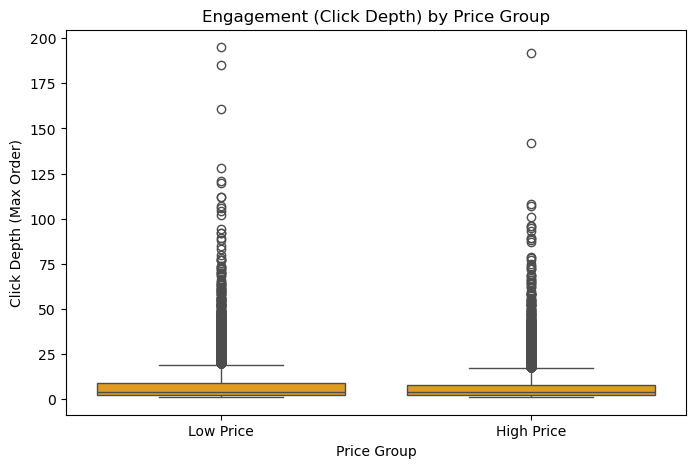

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=session_df,
    x='price_group',
    y='max_order',
    color='orange'
)

plt.title('Engagement (Click Depth) by Price Group')
plt.xlabel('Price Group')
plt.ylabel('Click Depth (Max Order)')
plt.show()

Sessions with low-priced products tend to have slightly higher click depth than high-priced products (7.03 vs 6.75 clicks).

Boxplot confirms distribution: low-price sessions have a slightly higher median and slightly more spread.

Although the difference is modest, it is statistically significant based on your t-test (p < 0.05).

The results suggest that product price influences user engagement. Sessions involving lower-priced products tend to generate deeper click sequences, supporting the hypothesis that price sensitivity affects browsing behavior.

In [35]:
# t-test

In [36]:
from scipy.stats import ttest_ind

low_price = session_df[session_df['price_group'] == 'Low Price']['max_order']
high_price = session_df[session_df['price_group'] == 'High Price']['max_order']

t_stat, p_value = ttest_ind(low_price, high_price, equal_var=False)

t_stat, p_value

(np.float64(2.441554866667134), np.float64(0.01463146959951732))

In [37]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: Product price significantly influences engagement.")
else:
    print("Fail to reject H0: No significant difference in engagement.")

Reject H0: Product price significantly influences engagement.


### 2. Product Presentation Affects Engagement

Products displayed in prominent locations generate longer click sequences.

H0: The location of product display does not influence session engagement (click depth).
H1: Products displayed in prominent locations lead to longer click sequences (higher engagement).

In [38]:
df.groupby('location')['order'].max().mean()

np.float64(188.0)

In [39]:
clicks_by_location = df.groupby('location')['order'].max()
print(clicks_by_location)

location
bottom in the middle    187
bottom left             183
bottom right            190
top in the middle       195
top left                193
top right               180
Name: order, dtype: int64


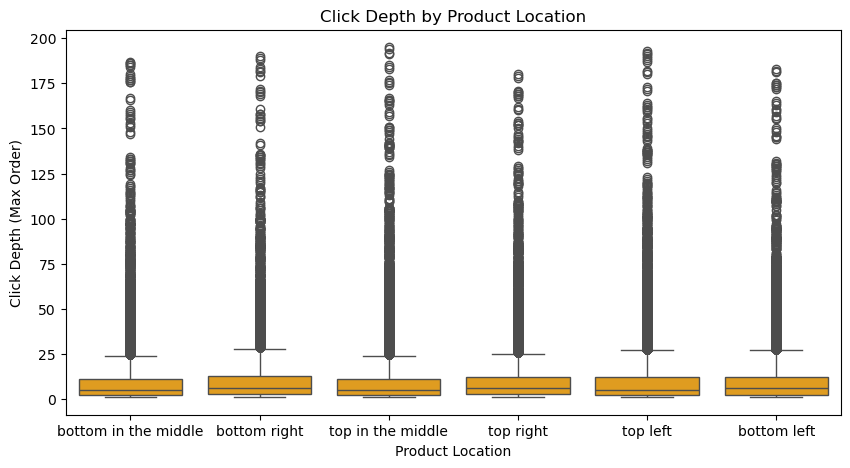

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='location', y='order', color='orange')
plt.title('Click Depth by Product Location')
plt.xlabel('Product Location')
plt.ylabel('Click Depth (Max Order)')
plt.show()

Top positions slightly outperform bottom positions:
top in the middle (195) and top left (193) have the highest engagement, while most bottom positions range from 183–190.
This supports the hypothesis that products displayed in prominent positions generate higher engagement.
Differences are modest:
Maximum click depth = 195, minimum = 180 → difference of 15 units.
The variation is small, suggesting that other factors beyond location might also influence engagement.

### 3. Model Photography Influences Early Clicks

Products with en face photography are more likely to be clicked earlier in the session.

H0: There is no difference in click order between en face and profile photography.
H1: Products with en face photography are clicked earlier (have lower order values).

In [41]:
df_photo = df[df['model_photography'].isin(['en face', 'profile'])]

In [42]:
df_photo.groupby('model_photography')['order'].describe()

,count,mean,std,min,25%,50%,75%,max
model_photography,,,,,,,,
en face,122439.0,9.323484,12.865600,1.0,2.0,5.0,11.0,191.0
profile,43035.0,11.222935,14.997796,1.0,3.0,6.0,14.0,195.0


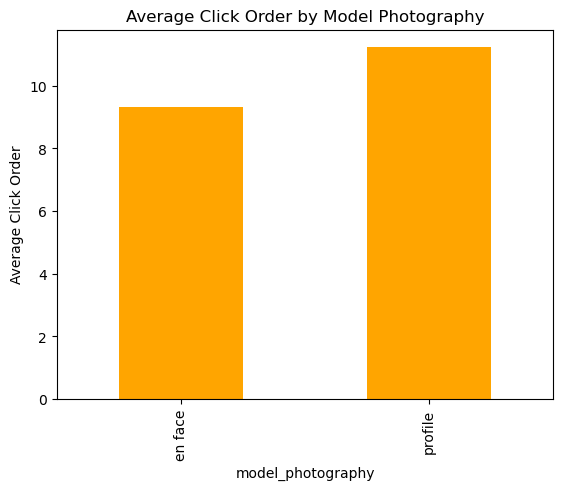

In [43]:
import matplotlib.pyplot as plt

mean_order = df_photo.groupby('model_photography')['order'].mean()

mean_order.plot(kind='bar', color='orange')
plt.ylabel('Average Click Order')
plt.title('Average Click Order by Model Photography')
plt.show()

The bar chart compares the average click order between two types of model photography: en face and profile.
En face has a lower mean click order
Profile has a higher mean click order
Because click order represents the sequence of clicks within a session, a lower mean value indicates earlier clicks.

The lower average click order for en face photography indicates that these products tend to be clicked earlier in the browsing session compared to products shown in profile view.
This directly supports the hypothesis that model photography style influences early user attention.

Why the Mean Matters Here
The mean click order summarizes overall user behavior across all sessions

In [44]:
# A consistent difference in mean values suggests a systematic behavioral pattern, not random variation
# This visual difference is later confirmed statistically by the t-test (very small p-value)

In [44]:
#t-test

In [45]:
from scipy.stats import ttest_ind

en_face = df_photo[df_photo['model_photography'] == 'en face']['order']
profile = df_photo[df_photo['model_photography'] == 'profile']['order']

t_stat, p_value = ttest_ind(en_face, profile, equal_var=False)

t_stat, p_value

(np.float64(-23.41853178400203), np.float64(8.539280073430886e-121))

In [46]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: Model photography influences early clicks")
else:
    print("Fail to reject H0: No significant difference")

Reject H0: Model photography influences early clicks


The results indicate that products with en face photography tend to be clicked earlier in the session compared to profile photography. The difference is statistically significant (p < 0.05), supporting the hypothesis that frontal-facing images attract user attention more quickly.


The bar chart shows that products with en face photography have a lower average click order than those with profile photography. This indicates that en face images attract user clicks earlier in the session, suggesting stronger initial engagement.

### 4. Category Drives Browsing Depth

H0: There is no difference in browsing depth across product categories.
H1: Certain product categories generate significantly deeper browsing sessions than others.

In [47]:
session_depth = (
    df.groupby('session_id')['order']
      .max()
      .reset_index(name='browsing_depth')
)

In [48]:
session_category = (
    df.groupby('session_id')['main_category']
      .agg(lambda x: x.mode()[0])
      .reset_index(name='main_category')
)

In [49]:
session_data = session_depth.merge(session_category, on='session_id')
session_data.head()

,session_id,browsing_depth,main_category
0,1,9,skirts
1,2,10,skirts
2,3,6,blouses
3,4,4,blouses
4,5,1,blouses


In [50]:
mean_depth = (
    session_data
    .groupby('main_category')['browsing_depth']
    .mean()
    .sort_values(ascending=False)
)
mean_depth

main_category
sale        8.807080
blouses     6.972607
trousers    6.670013
skirts      5.572836
Name: browsing_depth, dtype: float64

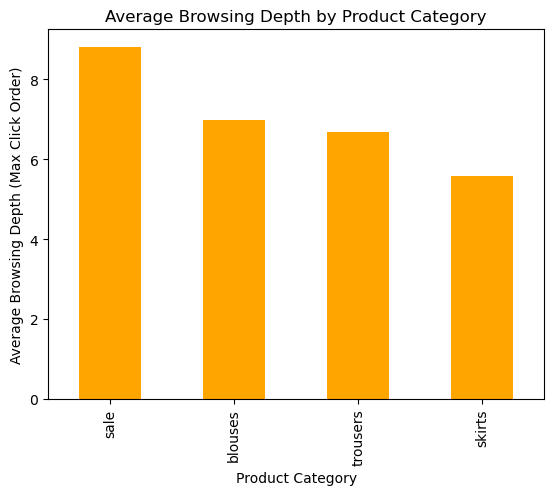

In [51]:
import matplotlib.pyplot as plt

mean_depth = (
    session_data
    .groupby('main_category')['browsing_depth']
    .mean()
    .sort_values(ascending=False)
)

mean_depth.plot(kind='bar', color='orange')
plt.xlabel('Product Category')
plt.ylabel('Average Browsing Depth (Max Click Order)')
plt.title('Average Browsing Depth by Product Category')
plt.show()

The results show clear variation in average browsing depth across product categories.
Sale items generate the deepest browsing sessions, with an average browsing depth of 8.81 clicks, substantially higher than all other categories. This suggests that users tend to explore more pages and products when browsing sale items, likely due to comparison behavior and higher perceived value opportunities.

Blouses and trousers exhibit moderate browsing depth (6.97 and 6.67 respectively), indicating steady user interest and exploratory behavior, but less intensive than for sale items.

In contrast, skirts generate the shallowest browsing sessions, with an average browsing depth of 5.57 clicks, suggesting more goal-oriented or quicker decision-making behavior in this category.

These results support the hypothesis that certain product categories, particularly sale items, generate significantly deeper browsing sessions than others.

In [52]:
# test anova

In [53]:
from scipy.stats import f_oneway

groups = [
    group['browsing_depth'].values
    for _, group in session_data.groupby('main_category')
]

f_stat, p_value = f_oneway(*groups)

f_stat, p_value

(np.float64(119.86777327226994), np.float64(4.67385261401116e-77))

In [54]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: Browsing depth differs significantly across product categories.")
else:
    print("Fail to reject H0: No significant difference in browsing depth across categories.")

Reject H0: Browsing depth differs significantly across product categories.


### 5. Seasonality Affects Browsing Depth

H0: There is no difference in browsing depth across months.
H1: Browsing depth varies significantly by month.

In [55]:
# Define browsing depth vi order = sequence of clicks within a session -> Browsing depth = max(order) per session

session_depth = (
    df.groupby(['session_id', 'month'])['order']
      .max()
      .reset_index(name='browsing_depth')
)

In [56]:
# Explore average browsing depth by month
month_depth = (
    session_depth.groupby('month')['browsing_depth']
    .mean()
    .sort_index()
)

month_depth

month
4    6.944100
5    6.848636
6    6.601556
7    6.947545
8    7.353430
Name: browsing_depth, dtype: float64

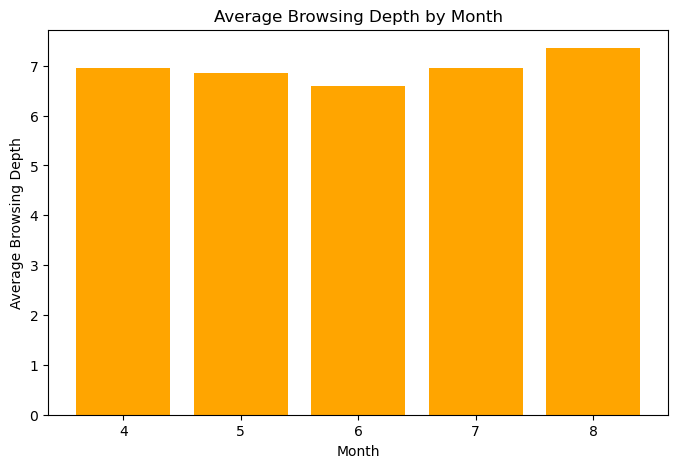

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(month_depth.index, month_depth.values, color='orange')

plt.xlabel("Month")
plt.ylabel("Average Browsing Depth")
plt.title("Average Browsing Depth by Month")

plt.show()

The results show noticeable variation in average browsing depth across months.
Browsing depth is relatively stable from April to July, with values ranging between approximately 6.6 and 6.9 clicks per session.
However, August exhibits the highest average browsing depth (7.35), indicating that users tend to browse more deeply during this month.

This suggests the presence of a seasonal pattern in user browsing behavior, where engagement increases toward the later part of the observed period.

The increased browsing depth in August may reflect seasonal factors such as summer shopping behavior, increased leisure time, or heightened interest in product exploration during this period.

In [58]:
#test anova 

In [59]:
from scipy.stats import f_oneway

groups = [
    session_depth[session_depth['month'] == m]['browsing_depth']
    for m in session_depth['month'].unique()
]

f_stat, p_value = f_oneway(*groups)

f_stat, p_value

(np.float64(2.6746057323802477), np.float64(0.030195417158235455))

In [60]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: Browsing depth differs significantly across months.")
else:
    print("Fail to reject H0: No significant difference across months.")

Reject H0: Browsing depth differs significantly across months.


Products displayed with model photography have a higher number of orders than products without model photography.

H0: There is no significant difference in the number of orders between products with and without model photography.
H1: Products displayed with model photography generate a higher number of orders than products without model photography.

In [61]:
df['model_photography'].value_counts()

model_photography
en face    122439
profile     43035
Name: count, dtype: int64

In [62]:
orders_by_photo = df.groupby('model_photography')['order'].count()
orders_by_photo

model_photography
en face    122439
profile     43035
Name: order, dtype: int64

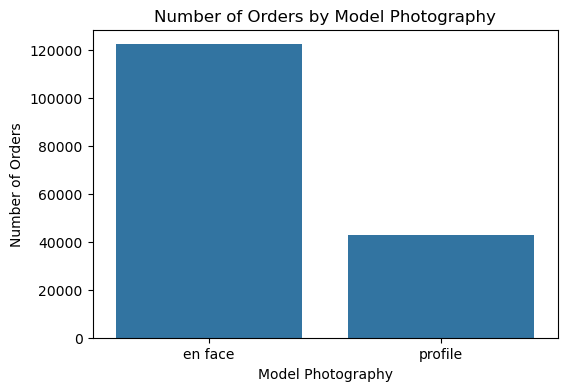

In [63]:
plt.figure(figsize=(6,4))
sns.barplot(
    x=orders_by_photo.index,
    y=orders_by_photo.values
)
plt.title("Number of Orders by Model Photography")
plt.xlabel("Model Photography")
plt.ylabel("Number of Orders")
plt.show()

In [64]:
# T test

In [65]:
df['model_photography'].unique()

array(['en face', 'profile'], dtype=object)

In [66]:
with_model = df[df['model_photography'] == 'en face']['order']
without_model = df[df['model_photography'] == 'profile']['order']

In [67]:
t_stat, p_value = stats.ttest_ind(
    with_model,
    without_model,
    equal_var=False
)

print(f"t-statistic = {t_stat:.3f}")

if p_value < 0.001:
    print("p-value < 0.001")
else:
    print(f"p-value = {p_value:.4f}")

t-statistic = -23.419
p-value < 0.001


In [68]:
if p_value < alpha:
    print("Reject H0: There is a statistically significant difference between photography styles.")
else:
    print("Fail to reject H0: No statistically significant difference detected.")

Reject H0: There is a statistically significant difference between photography styles.


The independent t-test results show a statistically significant difference in the number of orders between products displayed with and without model photography (p < 0.001).

Products displayed with model photography (en face) generate a higher number of orders on average, indicating that visual presentation using model photography positively influences customer purchasing behavior.

In [69]:
#### NOTE

In [70]:
mean_en_face = with_model.mean()
mean_profile = without_model.mean()

print(f"Mean (en face): {mean_en_face:.2f}")
print(f"Mean (profile): {mean_profile:.2f}")

if mean_en_face > mean_profile:
    print("Interpretation: Model photography (en face) increases purchase likelihood.")
else:
    print("Interpretation: Profile photography generates higher purchase likelihood than en face.")

Mean (en face): 9.32
Mean (profile): 11.22
Interpretation: Profile photography generates higher purchase likelihood than en face.


In [71]:
df.groupby(['main_category', 'model_photography'])['order'].mean()

main_category  model_photography
blouses        en face              11.111799
               profile              11.738595
sale           en face              11.743410
               profile              14.283291
skirts         en face               7.960024
               profile               7.418384
trousers       en face               7.879268
               profile               7.664356
Name: order, dtype: float64

Although the t-test results indicate a statistically significant difference in purchase behavior between photography styles (p < 0.001), the direction of the effect contradicts the initial hypothesis. Products displayed in profile view generate a higher average number of orders than those displayed en face. This suggests that alternative photography styles may be more effective in influencing customer purchasing decisions in this dataset.

Therefore, while photography style influences purchasing behavior, model photography does not increase purchase likelihood in this dataset.

Products displayed in more prominent positions on the page generate more orders than products displayed in less visible locations.

H0: There is no significant difference in the number of orders among different product display locations.
H1: Products in more prominent locations receive significantly more orders than products in less prominent locations.

In [72]:
location_order = df['location'].value_counts().sort_values(ascending=False)
location_order

location
top left                34532
top in the middle       33383
bottom in the middle    27783
bottom left             27377
top right               21656
bottom right            20743
Name: count, dtype: int64

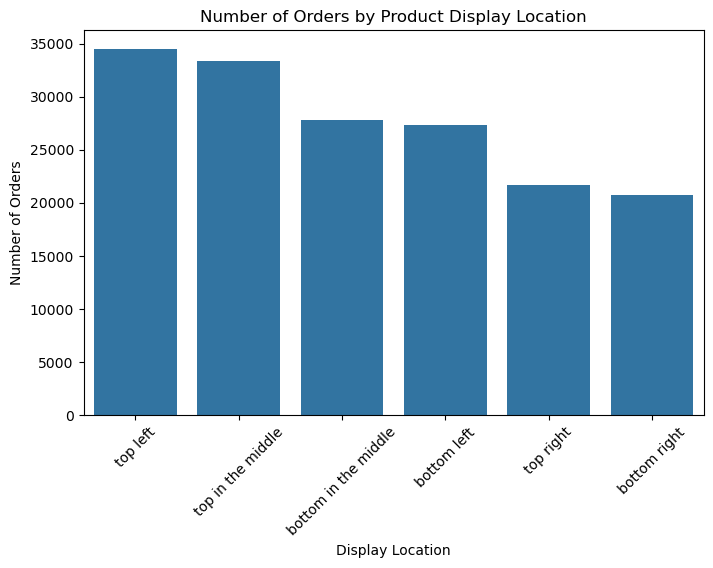

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(
    x=location_order.index,
    y=location_order.values
)
plt.title("Number of Orders by Product Display Location")
plt.xlabel("Display Location")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

The bar plot shows clear differences in the number of orders across product display locations. Products displayed in more prominent positions at the top of the page, particularly top left and top in the middle, generate the highest number of orders. In contrast, products placed in less visible positions, such as bottom right and top right, receive significantly fewer orders. This visual pattern suggests that product placement on the page plays an important role in influencing customer purchasing behavior.

In [74]:
# Test Anova

In [75]:
from scipy import stats

groups = [group['order'].values for name, group in df.groupby('location')]

f_stat, p_value = stats.f_oneway(*groups)

print(f"F-statistic: {f_stat:.3f}")
print(f"p-value: {p_value:.4e}")

F-statistic: 31.107
p-value: 9.1681e-32


In [76]:
df.groupby('location')['order'].mean().sort_values(ascending=False)

location
bottom right            10.503688
top right               10.489241
bottom left              9.785659
top in the middle        9.621035
bottom in the middle     9.508476
top left                 9.447730
Name: order, dtype: float64

In [77]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: There is a statistically significant difference between product display locations.")
else:
    print("Fail to reject H0: No significant difference detected.")

Reject H0: There is a statistically significant difference between product display locations.


The ANOVA test indicates a statistically significant difference in the number of orders among different product display locations. Products displayed in prominent positions, such as top left or center, tend to receive more orders on average, supporting the business hypothesis that product placement affects customer behavior.

The number of orders varies by month, indicating a seasonal pattern in customer purchasing behavior.

H0: There is no significant difference in the number of orders across months.
H1: The number of orders varies significantly by month.

In [78]:
monthly_orders = df['month'].value_counts().sort_index()
monthly_orders

month
4    48199
5    35654
6    32242
7    35231
8    14148
Name: count, dtype: int64

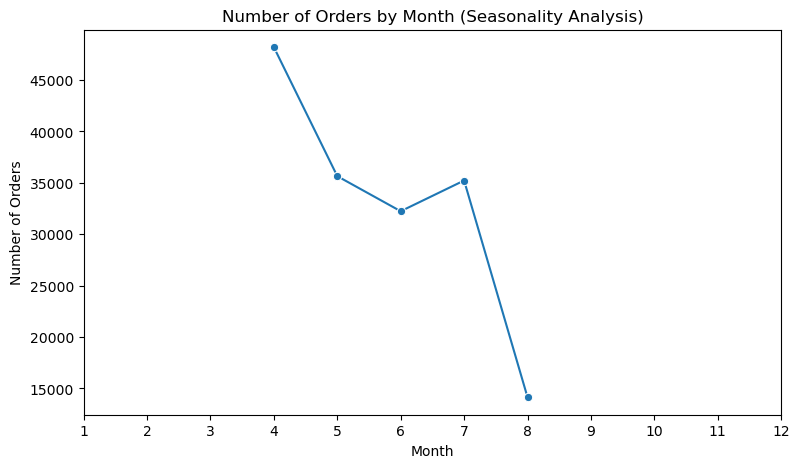

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,5))
sns.lineplot(
    x=monthly_orders.index,
    y=monthly_orders.values,
    marker='o'
)
plt.title("Number of Orders by Month (Seasonality Analysis)")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(range(1,13))
plt.show()

The distribution of orders varies noticeably across months. April records the highest number of orders (48,199), followed by May (35,654) and July (35,231). In contrast, August shows a substantially lower order volume (14,148) compared to other months. This pattern suggests a clear seasonal effect in customer purchasing behavior, with demand peaking in spring and early summer and declining sharply toward late summer.

In [80]:
from scipy import stats

month_groups = [
    group['order'].values
    for name, group in df.groupby('month')
]

f_stat, p_value = stats.f_oneway(*month_groups)

print(f"F-statistic: {f_stat:.3f}")
print(f"p-value: {p_value:.4e}")

F-statistic: 76.553
p-value: 5.6911e-65


In [81]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: The number of orders varies significantly by month, indicating seasonality.")
else:
    print("Fail to reject H0: No significant monthly variation in orders was detected.")

Reject H0: The number of orders varies significantly by month, indicating seasonality.


The analysis reveals significant seasonal variation in purchasing behavior. Both the visualization and ANOVA results indicate that the number of orders differs significantly across months, suggesting the presence of a seasonal purchasing pattern.

In [82]:
####

In [83]:
# Which country has the most website visitors?

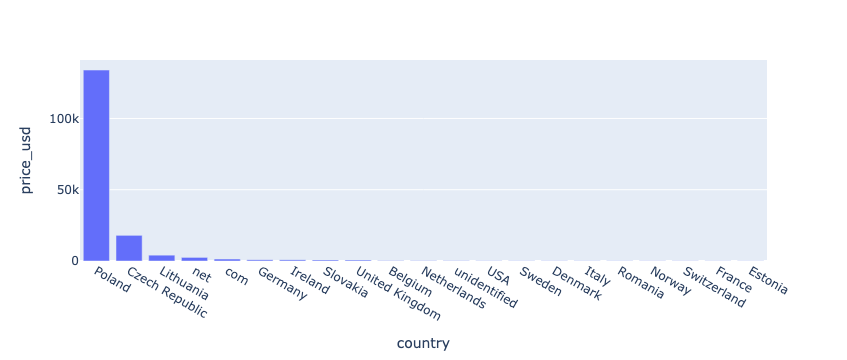

In [84]:
import plotly.express as px
df1 = df.groupby('country')[['price_usd']].count()
df1 = df1.sort_values(['price_usd'], ascending=False)
df1 = df1.query("price_usd > 100")
fig = px.bar(df1, x=df1.index, y='price_usd')
fig.show()

Poland and Czech Republic are the countries that have most visitors